# Kickstarter Funding Prediction — Efficient 3-Method Tuning + Ensembles (Kaggle)

This notebook implements the final experimental design:

- **10 baseline regressors**: Random Forest, Extra Trees, XGBoost, KNN, Ridge Regression, Linear Regression, SVR, Decision Tree, AdaBoost, CatBoost.
- **Three tuning methods** for every one of the 10 baselines: Randomized Search, Grid Search, and Bayesian Search.
- **5-fold shuffled CV**.
- **3 Randomized evaluations** and **3 Bayesian evaluations** per model.
- **Compact Grid Search** to prevent excessive runtime.
- **Stacking**: Random Forest + Extra Trees + XGBoost + CatBoost + SVR → Ridge meta-model.
- **Blending**: Random Forest + XGBoost + CatBoost with weights 25% / 35% / 40%.
- **Bagging**: Decision Tree base estimator.
- **Primary ranking metric**: RMSLE (lower is better).
- **Incremental checkpointing**: tuning results and final metrics are saved immediately after each completed model.
- The notebook is **resume-aware**: completed checkpoints are reused after a kernel/session restart.

> Important dependency note: Stacking must have its component models ready before it can be fitted. Therefore, a prerequisite stage tunes/caches all 10 baselines before the requested final evaluation order is executed. The **final model results are still saved/displayed in the exact requested order**.


## 1. Imports and Kaggle setup

This notebook is designed for Kaggle. It requires:
- scikit-learn
- xgboost
- catboost
- scikit-optimize (`skopt`) for Bayesian tuning

The notebook does not silently install packages during a long run. Missing `skopt` is reported immediately at startup.

In [1]:
import sys, subprocess, importlib.util, os, time, json, warnings, shutil
from pathlib import Path

warnings.filterwarnings("ignore")

if importlib.util.find_spec("skopt") is None:
    raise ImportError(
        "scikit-optimize is required for BayesSearchCV. "
        "Install/enable the package in the Kaggle environment before running this notebook."
    )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import KFold, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor, BaggingRegressor, StackingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, r2_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
print("Environment ready.")


Environment ready.


## 2. Runtime configuration and checkpoint paths

In [2]:

# ============================================================
# EXPERIMENT CONFIGURATION
# ============================================================
RANDOM_STATE = 42
N_SPLITS = 5
N_ITER = 3                 # Randomized Search and Bayesian Search
SCORING = "neg_mean_squared_error"
SEARCH_N_JOBS = -1         # parallelize CV/search across available CPU threads

CV = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Kaggle output directory
OUTPUT_DIR = Path("/kaggle/working/kickstarter_ensemble_checkpoints")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TUNING_CSV = OUTPUT_DIR / "tuning_results_checkpoint.csv"
FINAL_CSV = OUTPUT_DIR / "final_metrics_checkpoint.csv"
PREDICTIONS_CSV = OUTPUT_DIR / "predictions_checkpoint.csv"
STATUS_JSON = OUTPUT_DIR / "experiment_status.json"

# Use GPU for XGBoost/CatBoost only when explicitly available in the environment.
# Kaggle notebook should be run with GPU enabled for GPU acceleration.
try:
    import torch
    GPU_AVAILABLE = bool(torch.cuda.is_available())
except Exception:
    GPU_AVAILABLE = False

print(f"5-fold CV | {N_ITER} randomized iterations | {N_ITER} Bayesian iterations")
print("GPU detected:", GPU_AVAILABLE)
print("Checkpoint directory:", OUTPUT_DIR)


5-fold CV | 3 randomized iterations | 3 Bayesian iterations
GPU detected: True
Checkpoint directory: /kaggle/working/kickstarter_ensemble_checkpoints


## 3. Load ML_train.csv and ML_test.csv

In [3]:

KAGGLE_INPUT_ROOT = Path("/kaggle/input/datasets/omorfaruq/ml-dataset-kickstarter/ML dataset")

train_matches = sorted(KAGGLE_INPUT_ROOT.rglob("ML_train.csv"))
test_matches = sorted(KAGGLE_INPUT_ROOT.rglob("ML_test.csv"))

if not train_matches or not test_matches:
    raise FileNotFoundError(
        "ML_train.csv and ML_test.csv were not found under /kaggle/input. "
        "Attach the dataset containing these files to the Kaggle notebook."
    )

TRAIN_FILE = train_matches[0]
TEST_FILE = test_matches[0]

train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)

print("TRAIN:", TRAIN_FILE)
print("TEST :", TEST_FILE)
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
display(train_df.head())


TRAIN: /kaggle/input/datasets/omorfaruq/ml-dataset-kickstarter/ML dataset/ML_train.csv
TEST : /kaggle/input/datasets/omorfaruq/ml-dataset-kickstarter/ML dataset/ML_test.csv
Train shape: (16000, 81)
Test shape : (4000, 81)


,id,goal_usd,log_goal_usd,duration_days,prelaunch_days,name_char_length,name_word_count,blurb_char_length,blurb_word_count,launch_year,launch_month,launch_day,launch_weekday,launch_hour,has_video,prelaunch_activated,category_name_freq,location_country_freq,location_state_freq,country_AU,country_BE,country_CA,country_CH,country_DE,country_DK,country_ES,country_FR,country_GB,country_GR,country_HK,country_IE,country_IT,country_JP,country_LU,country_MX,country_NL,country_NO,country_NZ,country_PL,country_SE,country_SG,country_SI,country_US,currency_CAD,currency_CHF,currency_DKK,currency_EUR,currency_GBP,currency_HKD,currency_JPY,currency_MXN,currency_NOK,currency_NZD,currency_PLN,currency_SEK,currency_SGD,currency_USD,category_parent_Comics,category_parent_Crafts,category_parent_Dance,category_parent_Design,category_parent_Fashion,category_parent_Film & Video,category_parent_Food,category_parent_Games,category_parent_Journalism,category_parent_Music,category_parent_Photography,category_parent_Publishing,category_parent_Technology,category_parent_Theater,location_type_County,location_type_Island,location_type_LocalAdmin,location_type_Miscellaneous,location_type_Suburb,location_type_Town,location_type_Unknown,location_type_Zip,target_usd,log_target
0,160053502,1490.1241,7.307286,30.000000,13.537003,30.0,5.0,25.0,5.0,2020.0,6.0,8.0,0.0,15.0,1.0,1.0,0.006625,0.045937,0.009750,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2694.360622,7.899287
1,1797462698,5000.0000,8.517393,35.041668,18.665070,8.0,2.0,108.0,18.0,2017.0,10.0,17.0,1.0,13.0,1.0,0.0,0.009813,0.622313,0.037000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,122.000000,4.812184
2,1582340481,10000.0000,9.210441,30.000000,10.058495,53.0,7.0,108.0,13.0,2025.0,1.0,3.0,4.0,2.0,1.0,0.0,0.006125,0.622313,0.106500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.000000
3,498571554,15475.7350,9.647093,29.958334,7.044641,39.0,7.0,110.0,18.0,2022.0,3.0,11.0,4.0,12.0,0.0,1.0,0.015813,0.003125,0.001500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,26102.038065,10.169807
4,1914908476,1400.0000,7.244942,60.000000,13.044236,29.0,5.0,125.0,24.0,2025.0,3.0,23.0,6.0,21.0,1.0,0.0,0.011187,0.622313,0.033125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1478.000000,7.299121


## 4. Feature/target split and scaling

- `X_train` / `X_test`: all columns except `id`, `target_usd`, `log_target`, `goal_usd`.
- Target is `log_target` (log1p of `target_usd`), predicted on the log scale and converted back with `expm1` at evaluation time.
- A `StandardScaler` is fit on `X_train` and applied to both `X_train`/`X_test`; scaled versions are used only by the models that need them (KNN, Ridge, Linear Regression, SVR), which wrap the scaler inside a `Pipeline` so cross-validation never leaks scaling statistics from validation folds.


In [4]:

TARGET_RAW = "target_usd"
TARGET_LOG = "log_target"

DROP_FROM_X = ["id", TARGET_RAW, TARGET_LOG, "goal_usd"]

X_train = train_df.drop(columns=DROP_FROM_X, errors="ignore").copy()
X_test = test_df.drop(columns=DROP_FROM_X, errors="ignore").copy()

y_train = train_df[TARGET_LOG].copy()
y_test = test_df[TARGET_LOG].copy()
actual_usd = test_df[TARGET_RAW].to_numpy(dtype=float)

assert list(X_train.columns) == list(X_test.columns), "Train/test feature columns differ."
assert X_train.isna().sum().sum() == 0, "Missing values found in X_train."
assert X_test.isna().sum().sum() == 0, "Missing values found in X_test."
assert TARGET_LOG not in X_train.columns
assert TARGET_RAW not in X_train.columns

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features:", X_train.shape[1])
print("Training samples:", len(X_train))
print("Test samples:", len(X_test))
print("Scaled models: KNN, Ridge, Linear Regression, SVR")


Features: 77
Training samples: 16000
Test samples: 4000
Scaled models: KNN, Ridge, Linear Regression, SVR


## 5. Evaluation and checkpoint helpers

In [5]:

METRIC_COLUMNS = [
    "Model", "Best_Tuning_Method",
    "MAE_log", "MSE_log", "RMSE_log", "R2_log",
    "MAE_USD", "MSE_USD", "RMSE_USD", "R2_USD",
    "RMSLE", "Training_Time_Seconds"
]

def evaluate_predictions(model_name, y_true_log, pred_log, actual_usd):
    pred_log = np.asarray(pred_log, dtype=float)
    pred_usd = np.clip(np.expm1(pred_log), 0, None)
    actual_usd = np.asarray(actual_usd, dtype=float)

    mse_log = mean_squared_error(y_true_log, pred_log)
    mse_usd = mean_squared_error(actual_usd, pred_usd)

    metrics = {
        "Model": model_name,
        "MAE_log": mean_absolute_error(y_true_log, pred_log),
        "MSE_log": mse_log,
        "RMSE_log": np.sqrt(mse_log),
        "R2_log": r2_score(y_true_log, pred_log),
        "MAE_USD": mean_absolute_error(actual_usd, pred_usd),
        "MSE_USD": mse_usd,
        "RMSE_USD": np.sqrt(mse_usd),
        "R2_USD": r2_score(actual_usd, pred_usd),
        "RMSLE": np.sqrt(mean_squared_log_error(actual_usd, pred_usd)),
    }
    return metrics, pred_usd

def atomic_to_csv(df, path):
    tmp = Path(str(path) + ".tmp")
    df.to_csv(tmp, index=False)
    tmp.replace(path)

def load_checkpoint(path, key_col):
    if Path(path).exists():
        try:
            df = pd.read_csv(path)
            if key_col in df.columns:
                return df
        except Exception as e:
            print(f"Warning: could not read {path}: {e}")
    return pd.DataFrame()

tuning_checkpoint = load_checkpoint(TUNING_CSV, "Model")
final_checkpoint = load_checkpoint(FINAL_CSV, "Model")

print("Existing tuning rows:", len(tuning_checkpoint))
print("Existing final rows :", len(final_checkpoint))


Existing tuning rows: 0
Existing final rows : 0


## 6. Model definitions and compact search spaces

In [6]:
# ------------------------------------------------------------
# MODEL DEFINITIONS + COMPACT SEARCH SPACES
# ------------------------------------------------------------
# IMPORTANT:
# Models that use StandardScaler are wrapped in Pipelines.
# Therefore every hyperparameter of the inner "model" step MUST
# use the "model__" prefix in Randomized/Grid/Bayesian searches.

# ------------------------------------------------------------
# GPU-safety note:
# GPU boosters (XGBoost/CatBoost) each occupy the *same physical GPU*.
# RandomizedSearchCV/GridSearchCV/BayesSearchCV with n_jobs=-1 fit many
# folds/candidates in parallel worker PROCESSES; if the estimator is a
# GPU booster, that means many simultaneous GPU allocations on one card,
# which reliably OOMs (CatBoost's GPU trainer is memory-hungry enough
# that this happens even on a T4 with only a handful of folds).
# The fix: hyperparameter SEARCH always uses the CPU estimator (safe to
# parallelize across CPU cores with n_jobs=-1); the FINAL single fit
# (done once per model, no parallel contention) uses the GPU estimator
# for speed. "tuning_estimator" below is CPU-only; "estimator" uses GPU
# when available and is only ever fit once at a time.
# ------------------------------------------------------------
XGB_COMMON_CPU = dict(
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=RANDOM_STATE,
    n_jobs=1,
    tree_method="hist",
    device="cpu",
)
CAT_COMMON_CPU = dict(
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    task_type="CPU",
    thread_count=1,
)

if GPU_AVAILABLE:
    XGB_COMMON = dict(
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=RANDOM_STATE,
        n_jobs=1,
        tree_method="hist",
        device="cuda",
    )
    CAT_COMMON = dict(
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
        task_type="GPU",
        devices="0",
        thread_count=1,
        # Cap per-process GPU memory so that even if something *does* run
        # concurrently, a single run cannot claim the whole card.
        gpu_ram_part=0.45,
    )
else:
    XGB_COMMON = dict(XGB_COMMON_CPU)
    CAT_COMMON = dict(CAT_COMMON_CPU)

MODEL_CONFIGS = {
    "Random Forest": {
        "estimator": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
        "random": {
            "n_estimators": [200, 400, 600],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", "log2", 0.7],
        },
        "grid": {
            "n_estimators": [200, 400],
            "max_depth": [None, 15],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2],
            "max_features": ["sqrt"],
        },
        "bayes": {
            "n_estimators": Integer(200, 600),
            "max_depth": Integer(8, 25),
            "min_samples_split": Integer(2, 8),
            "min_samples_leaf": Integer(1, 4),
            "max_features": Categorical(["sqrt", "log2", 0.7]),
        },
    },

    "Extra Trees": {
        "estimator": ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=1),
        "random": {
            "n_estimators": [200, 400, 600],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", "log2", 0.7],
        },
        "grid": {
            "n_estimators": [200, 400],
            "max_depth": [None, 15],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2],
            "max_features": ["sqrt"],
        },
        "bayes": {
            "n_estimators": Integer(200, 600),
            "max_depth": Integer(8, 25),
            "min_samples_split": Integer(2, 8),
            "min_samples_leaf": Integer(1, 4),
            "max_features": Categorical(["sqrt", "log2", 0.7]),
        },
    },

    "XGBoost": {
        "estimator": XGBRegressor(**XGB_COMMON),
        "tuning_estimator": XGBRegressor(**XGB_COMMON_CPU),
        "random": {
            "n_estimators": [300, 500, 700],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.02, 0.05, 0.08],
            "min_child_weight": [1, 3, 5],
            "subsample": [0.8, 0.9, 1.0],
            "colsample_bytree": [0.8, 0.9, 1.0],
        },
        "grid": {
            "n_estimators": [300, 500],
            "max_depth": [3, 6],
            "learning_rate": [0.03, 0.05],
            "min_child_weight": [1, 3],
            "subsample": [0.9],
            "colsample_bytree": [0.9],
        },
        "bayes": {
            "n_estimators": Integer(300, 700),
            "max_depth": Integer(3, 8),
            "learning_rate": Real(0.02, 0.1, prior="log-uniform"),
            "min_child_weight": Integer(1, 6),
            "subsample": Real(0.8, 1.0),
            "colsample_bytree": Real(0.8, 1.0),
        },
    },

    "KNN": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsRegressor(n_jobs=1)),
        ]),
        "random": {
            "model__n_neighbors": list(range(3, 31)),
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
            "model__leaf_size": [15, 30, 45],
        },
        "grid": {
            "model__n_neighbors": [5, 10, 20],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
            "model__leaf_size": [20, 30],
        },
        "bayes": {
            "model__n_neighbors": Integer(3, 30),
            "model__weights": Categorical(["uniform", "distance"]),
            "model__p": Integer(1, 2),
            "model__leaf_size": Integer(15, 50),
        },
    },

    "Ridge Regression": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge()),
        ]),
        "random": {
            "model__alpha": list(np.logspace(-3, 3, 30)),
            "model__solver": ["auto", "lsqr", "sag"],
        },
        "grid": {
            "model__alpha": [0.1, 1.0, 10.0],
            "model__solver": ["auto", "lsqr"],
        },
        "bayes": {
            "model__alpha": Real(1e-3, 1e3, prior="log-uniform"),
            "model__solver": Categorical(["auto", "lsqr", "sag"]),
        },
    },

    "Linear Regression": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression(n_jobs=1)),
        ]),
        "random": {
            "model__fit_intercept": [True, False],
            "model__positive": [True, False],
        },
        "grid": {
            "model__fit_intercept": [True, False],
            "model__positive": [False, True],
        },
        "bayes": {
            "model__fit_intercept": Categorical([True, False]),
            "model__positive": Categorical([True, False]),
        },
    },

    "SVR": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR(kernel="rbf")),
        ]),
        "random": {
            "model__C": list(np.logspace(-1, 3, 30)),
            "model__epsilon": [0.01, 0.05, 0.1, 0.2],
            "model__gamma": ["scale", "auto"],
        },
        "grid": {
            "model__C": [1, 10, 100],
            "model__epsilon": [0.05, 0.1],
            "model__gamma": ["scale"],
        },
        "bayes": {
            "model__C": Real(0.1, 1000, prior="log-uniform"),
            "model__epsilon": Real(0.01, 0.5, prior="log-uniform"),
            "model__gamma": Categorical(["scale", "auto"]),
        },
    },

    "Decision Tree": {
        "estimator": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "random": {
            "max_depth": [5, 8, 12, 16, 20, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": [None, "sqrt", "log2"],
        },
        "grid": {
            "max_depth": [8, 12, 16],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2],
            "max_features": [None, "sqrt"],
        },
        "bayes": {
            "max_depth": Integer(5, 25),
            "min_samples_split": Integer(2, 10),
            "min_samples_leaf": Integer(1, 5),
            "max_features": Categorical([None, "sqrt", "log2"]),
        },
    },

    "AdaBoost": {
        "estimator": AdaBoostRegressor(random_state=RANDOM_STATE),
        "random": {
            "n_estimators": [50, 100, 200, 300],
            "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
            "loss": ["linear", "square", "exponential"],
        },
        "grid": {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "loss": ["linear", "square"],
        },
        "bayes": {
            "n_estimators": Integer(50, 300),
            "learning_rate": Real(0.01, 0.3, prior="log-uniform"),
            "loss": Categorical(["linear", "square", "exponential"]),
        },
    },

    "CatBoost": {
        "estimator": CatBoostRegressor(**CAT_COMMON),
        "tuning_estimator": CatBoostRegressor(**CAT_COMMON_CPU),
        "random": {
            "iterations": [300, 500, 700],
            "depth": [4, 6, 8],
            "learning_rate": [0.02, 0.05, 0.08],
            "l2_leaf_reg": [1, 3, 5, 10],
            "random_strength": [0, 0.5, 1],
        },
        "grid": {
            "iterations": [300, 500],
            "depth": [5, 7],
            "learning_rate": [0.03, 0.05],
            "l2_leaf_reg": [1, 3],
            "random_strength": [0, 1],
        },
        "bayes": {
            "iterations": Integer(300, 700),
            "depth": Integer(4, 9),
            "learning_rate": Real(0.02, 0.1, prior="log-uniform"),
            "l2_leaf_reg": Real(1, 10, prior="log-uniform"),
            "random_strength": Real(0, 2),
        },
    },
}

TUNING_ORDER = [
    "XGBoost",
    "CatBoost",
    "Random Forest",
    "Extra Trees",
    "SVR",
    "Ridge Regression",
    "Linear Regression",
    "KNN",
    "AdaBoost",
    "Decision Tree",
]
TUNABLE_BASELINES = TUNING_ORDER.copy()

assert len(TUNABLE_BASELINES) == 10, (
    f"Expected 10 tunable baselines, got {len(TUNABLE_BASELINES)}"
)
print("Tunable baselines:", TUNABLE_BASELINES)


Tunable baselines: ['XGBoost', 'CatBoost', 'Random Forest', 'Extra Trees', 'SVR', 'Ridge Regression', 'Linear Regression', 'KNN', 'AdaBoost', 'Decision Tree']


## 7. Tuning functions with immediate checkpointing

All **10 baseline models** are tuned with:
- RandomizedSearchCV: **3 iterations**
- GridSearchCV: compact grid
- BayesSearchCV: **3 iterations**
- **5-fold CV**
- Immediate CSV checkpoint after every completed tuning method

Scaled models use sklearn Pipelines, and their inner-model parameters use the required `model__` prefix.

A **pre-flight validation runs before any expensive tuning** and checks every search-space parameter against `estimator.get_params(deep=True)`. This prevents Pipeline parameter-name errors from consuming Kaggle runtime.

In [7]:
# ============================================================
# SAFE CHECKPOINTING + THREE TUNING METHODS
# ============================================================

def json_safe(value):
    """Convert numpy/scikit-learn values to JSON-safe Python values."""
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (str, int, float, bool)) or value is None:
        return value
    return str(value)


def serialize_params(params):
    return json.dumps(json_safe(params), sort_keys=True, allow_nan=False)


def parse_params(params_text):
    """Read JSON checkpoints; safely support old checkpoints where possible."""
    if isinstance(params_text, dict):
        return params_text
    text = str(params_text).strip()
    if not text:
        return {}
    try:
        return json.loads(text)
    except Exception:
        # Legacy checkpoints may contain np.float64(...).
        # Only allow numpy names and no builtins.
        try:
            return eval(text, {"__builtins__": {}}, {"np": np})
        except Exception as exc:
            raise ValueError(
                f"Could not parse saved Best_Params: {text}"
            ) from exc


def validate_search_spaces():
    """
    Fail fast before expensive CV starts.

    Validation uses estimator.set_params() rather than only get_params().
    This is important for CatBoost, whose get_params() may not list every
    valid parameter until it has been explicitly set.

    It also catches Pipeline mistakes such as:
        weights            -> invalid for Pipeline
        model__weights     -> valid
    """
    errors = []

    for model_name, cfg in MODEL_CONFIGS.items():
        estimator = clone(cfg["estimator"])

        # Check cloneability.
        try:
            clone(estimator)
        except Exception as exc:
            errors.append(
                f"{model_name}: estimator cannot be cloned: "
                f"{type(exc).__name__}: {exc}"
            )
            continue

        # Random/Grid spaces contain ordinary candidate values, so they can
        # be validated directly with set_params().
        for method_key in ("random", "grid"):
            for key, values in cfg.get(method_key, {}).items():
                try:
                    if isinstance(values, (list, tuple, np.ndarray)):
                        candidate = values[0]
                    else:
                        candidate = values
                    clone(estimator).set_params(**{key: candidate})
                except Exception as exc:
                    errors.append(
                        f"{model_name} / {method_key}: invalid parameter "
                        f"'{key}': {type(exc).__name__}: {exc}"
                    )

        # Bayesian spaces must contain the same parameter names and are
        # validated by setting a representative value from the corresponding
        # RandomizedSearch space whenever available.
        random_space = cfg.get("random", {})
        for key in cfg.get("bayes", {}):
            if key in random_space:
                try:
                    candidate_values = random_space[key]
                    candidate = (
                        candidate_values[0]
                        if isinstance(candidate_values, (list, tuple, np.ndarray))
                        else candidate_values
                    )
                    clone(estimator).set_params(**{key: candidate})
                except Exception as exc:
                    errors.append(
                        f"{model_name} / BayesSearchCV: invalid parameter "
                        f"'{key}': {type(exc).__name__}: {exc}"
                    )
            else:
                errors.append(
                    f"{model_name} / BayesSearchCV: parameter '{key}' "
                    f"is not present in the RandomizedSearch space."
                )

    if errors:
        print("\nPRE-FLIGHT VALIDATION FAILED:")
        for err in errors:
            print(" -", err)
        raise RuntimeError(
            "Search-space validation failed. No expensive tuning was started."
        )

    print("✓ PRE-FLIGHT VALIDATION PASSED")
    print("✓ All tuning parameters are accepted by their estimators/Pipelines.")
    print("✓ All 10 estimators are cloneable.")


def tuning_record(model_name, method, search_obj, elapsed):
    best_mse = float(-search_obj.best_score_)
    return {
        "Model": model_name,
        "Method": method,
        "Best_CV_MSE_log": best_mse,
        "Best_CV_RMSE_log": float(np.sqrt(best_mse)),
        "Best_Params": serialize_params(search_obj.best_params_),
        "Tuning_Time_Seconds": float(elapsed),
    }


def append_tuning_record(record):
    global tuning_checkpoint

    row = pd.DataFrame([record])
    if len(tuning_checkpoint):
        tuning_checkpoint = tuning_checkpoint[
            ~(
                (tuning_checkpoint["Model"] == record["Model"]) &
                (tuning_checkpoint["Method"] == record["Method"])
            )
        ]

    tuning_checkpoint = pd.concat(
        [tuning_checkpoint, row], ignore_index=True
    )
    atomic_to_csv(tuning_checkpoint, TUNING_CSV)
    print(f"  ✓ Tuning checkpoint saved: {TUNING_CSV}")


def already_tuned(model_name, method):
    """
    Return True only when the checkpoint row exists AND its saved parameters
    are valid for the current estimator. Invalid/stale rows are automatically
    removed so an old buggy checkpoint cannot poison a new run.
    """
    global tuning_checkpoint

    if tuning_checkpoint is None or tuning_checkpoint.empty:
        return False

    mask = (
        (tuning_checkpoint["Model"] == model_name) &
        (tuning_checkpoint["Method"] == method)
    )
    rows = tuning_checkpoint.loc[mask]

    if rows.empty:
        return False

    try:
        for _, row in rows.iterrows():
            params = parse_params(row["Best_Params"])
            build_estimator_from_params(model_name, params)
        return True
    except Exception as exc:
        print(
            f"  ⚠ Invalid/stale checkpoint for {model_name}/{method}; "
            f"removing it and rerunning this method. Reason: {exc}"
        )
        tuning_checkpoint = tuning_checkpoint.loc[~mask].reset_index(drop=True)
        atomic_to_csv(tuning_checkpoint, TUNING_CSV)
        return False


def get_tuning_estimator(model_name):
    """
    Estimator used for the (parallel) CV search. GPU boosters use a CPU
    twin here so that n_jobs=-1 can safely fit many folds/candidates at
    once without multiple processes fighting over the same GPU. The GPU
    estimator (MODEL_CONFIGS[model_name]["estimator"]) is only ever used
    for the single final refit with the winning params.
    """
    cfg = MODEL_CONFIGS[model_name]
    return clone(cfg.get("tuning_estimator", cfg["estimator"]))


def _default_cv_record(model_name, method, X, y):
    start = time.time()
    scores = cross_val_score(
        get_tuning_estimator(model_name),
        X, y,
        scoring=SCORING,
        cv=CV,
        n_jobs=SEARCH_N_JOBS,
    )
    mse = float(-np.mean(scores))
    rec = {
        "Model": model_name,
        "Method": method,
        "Best_CV_MSE_log": mse,
        "Best_CV_RMSE_log": float(np.sqrt(mse)),
        "Best_Params": serialize_params({}),
        "Tuning_Time_Seconds": float(time.time() - start),
    }
    append_tuning_record(rec)
    print(
        f"  {method} (no tunable parameters) "
        f"RMSE_log: {rec['Best_CV_RMSE_log']:.6f}"
    )


def run_three_tuning_methods(model_name, X, y):
    cfg = MODEL_CONFIGS[model_name]

    print("\n" + "=" * 72)
    print(f"TUNING: {model_name}")
    print("=" * 72)

    # --------------------------------------------------------
    # 1. RandomizedSearchCV
    # --------------------------------------------------------
    if not already_tuned(model_name, "RandomizedSearchCV"):
        if not cfg["random"]:
            _default_cv_record(model_name, "RandomizedSearchCV", X, y)
        else:
            start = time.time()
            search = RandomizedSearchCV(
                estimator=get_tuning_estimator(model_name),
                param_distributions=cfg["random"],
                n_iter=N_ITER,
                scoring=SCORING,
                cv=CV,
                random_state=RANDOM_STATE,
                n_jobs=SEARCH_N_JOBS,
                refit=True,
                error_score="raise",
            )
            search.fit(X, y)
            rec = tuning_record(
                model_name, "RandomizedSearchCV", search, time.time() - start
            )
            append_tuning_record(rec)
            print(
                f"  Randomized best RMSE_log: "
                f"{rec['Best_CV_RMSE_log']:.6f}"
            )
    else:
        print("  RandomizedSearchCV already checkpointed; skipping.")

    # --------------------------------------------------------
    # 2. GridSearchCV
    # --------------------------------------------------------
    if not already_tuned(model_name, "GridSearchCV"):
        if not cfg["grid"]:
            _default_cv_record(model_name, "GridSearchCV", X, y)
        else:
            start = time.time()
            search = GridSearchCV(
                estimator=get_tuning_estimator(model_name),
                param_grid=cfg["grid"],
                scoring=SCORING,
                cv=CV,
                n_jobs=SEARCH_N_JOBS,
                refit=True,
                error_score="raise",
            )
            search.fit(X, y)
            rec = tuning_record(
                model_name, "GridSearchCV", search, time.time() - start
            )
            append_tuning_record(rec)
            print(
                f"  Grid best RMSE_log: "
                f"{rec['Best_CV_RMSE_log']:.6f}"
            )
    else:
        print("  GridSearchCV already checkpointed; skipping.")

    # --------------------------------------------------------
    # 3. Bayesian Search
    # --------------------------------------------------------
    if not already_tuned(model_name, "BayesSearchCV"):
        if not cfg["bayes"]:
            _default_cv_record(model_name, "BayesSearchCV", X, y)
        else:
            start = time.time()
            search = BayesSearchCV(
                estimator=get_tuning_estimator(model_name),
                search_spaces=cfg["bayes"],
                n_iter=N_ITER,
                scoring=SCORING,
                cv=CV,
                random_state=RANDOM_STATE,
                n_jobs=SEARCH_N_JOBS,
                refit=True,
                error_score="raise",
            )
            search.fit(X, y)
            rec = tuning_record(
                model_name, "BayesSearchCV", search, time.time() - start
            )
            append_tuning_record(rec)
            print(
                f"  Bayesian best RMSE_log: "
                f"{rec['Best_CV_RMSE_log']:.6f}"
            )
    else:
        print("  BayesSearchCV already checkpointed; skipping.")


def native_params(params):
    return json_safe(params)


def build_estimator_from_params(model_name, params):
    est = clone(MODEL_CONFIGS[model_name]["estimator"])
    safe_params = native_params(params)

    # NOTE: We deliberately do NOT pre-check keys against
    # est.get_params(deep=True) here. For a freshly-constructed,
    # never-fit CatBoostRegressor, get_params(deep=True) does not yet
    # list hyperparameters like "depth"/"iterations"/"learning_rate"
    # until set_params() has been called with them at least once - so
    # a membership check flags perfectly valid CatBoost params as
    # "invalid". Instead, attempt set_params() directly and only raise
    # if the estimator itself rejects a key (this mirrors the approach
    # already used in validate_search_spaces()).
    try:
        est.set_params(**safe_params)
    except Exception as exc:
        raise ValueError(
            f"Checkpoint for {model_name} contains invalid parameters "
            f"{sorted(safe_params.keys())}: {type(exc).__name__}: {exc}. "
            f"Delete only that model's stale tuning rows and rerun it."
        ) from exc

    return est


def get_winning_params(model_name):
    rows = tuning_checkpoint[
        tuning_checkpoint["Model"].eq(model_name)
    ].copy()

    expected_methods = {
        "RandomizedSearchCV",
        "GridSearchCV",
        "BayesSearchCV",
    }

    if rows.empty or set(rows["Method"]) != expected_methods:
        found = sorted(rows["Method"].tolist()) if len(rows) else []
        raise RuntimeError(
            f"Incomplete tuning checkpoint for {model_name}. "
            f"Expected all 3 methods; found {found}."
        )

    idx = rows["Best_CV_MSE_log"].astype(float).idxmin()
    winner = rows.loc[idx]

    return (
        winner["Method"],
        parse_params(winner["Best_Params"]),
        float(winner["Best_CV_MSE_log"]),
    )


def tune_or_recover_model(model_name):
    X = X_train
    y = y_train

    run_three_tuning_methods(model_name, X, y)

    method, params, cv_mse = get_winning_params(model_name)
    estimator = build_estimator_from_params(model_name, params)

    # Fit once with the winning parameters for downstream ensemble use.
    start = time.time()
    estimator.fit(X, y)
    fit_time = time.time() - start

    return estimator, method, fit_time, cv_mse


### 7.1 Pre-flight validation (must pass before Section 8 runs)


In [8]:
# ------------------------------------------------------------
# PRE-FLIGHT: run validate_search_spaces() before any expensive tuning
# ------------------------------------------------------------
# This calls the validator defined above and fails fast (with a clear
# list of every bad parameter) instead of burning CV/GPU time only to
# crash deep inside a RandomizedSearchCV/.fit() call, as happened when
# this notebook was run without calling this check first.
validate_search_spaces()

# Extra belt-and-braces check specifically for the Pipeline-wrapped
# models (KNN, Ridge Regression, Linear Regression, SVR): every key in
# their search spaces must be prefixed with "model__", since sklearn
# routes bare parameter names to the Pipeline itself, not to the
# wrapped estimator.
_pipeline_errors = []
for _name, _cfg in MODEL_CONFIGS.items():
    if isinstance(_cfg["estimator"], Pipeline):
        for _method_key in ("random", "grid", "bayes"):
            _bad = [k for k in _cfg[_method_key] if not k.startswith("model__")]
            if _bad:
                _pipeline_errors.append(f"{_name}/{_method_key}: missing 'model__' prefix on {_bad}")

if _pipeline_errors:
    print("\nPIPELINE PARAMETER-PREFIX CHECK FAILED:")
    for _err in _pipeline_errors:
        print(" -", _err)
    raise RuntimeError("Pipeline parameter prefix validation failed. Fix MODEL_CONFIGS before tuning.")

print("✓ Pipeline parameter-prefix check passed for KNN, Ridge Regression, Linear Regression, SVR.")


✓ PRE-FLIGHT VALIDATION PASSED
✓ All tuning parameters are accepted by their estimators/Pipelines.
✓ All 10 estimators are cloneable.
✓ Pipeline parameter-prefix check passed for KNN, Ridge Regression, Linear Regression, SVR.


## 8. Tune/cache all 10 baselines once (dependency preparation)

In [9]:
# Prepare/cache all 10 tuned baselines.
# Each of the three search methods checkpoints immediately.
# Final estimators are fitted once from the winning parameters.

tuned_models = {}
tuned_methods = {}
tuned_fit_times = {}
tuned_cv_mse = {}

for model_name in TUNABLE_BASELINES:
    estimator, method, fit_time, cv_mse = tune_or_recover_model(model_name)
    tuned_models[model_name] = estimator
    tuned_methods[model_name] = method
    tuned_fit_times[model_name] = fit_time
    tuned_cv_mse[model_name] = cv_mse
    print(f"{model_name}: winner={method}, CV RMSE_log={np.sqrt(cv_mse):.5f}, final fit={fit_time:.2f}s")

print("\nAll 10 baseline tuning checkpoints are complete.")



TUNING: XGBoost
  ✓ Tuning checkpoint saved: /kaggle/working/kickstarter_ensemble_checkpoints/tuning_results_checkpoint.csv
  Randomized best RMSE_log: 2.264920
  ✓ Tuning checkpoint saved: /kaggle/working/kickstarter_ensemble_checkpoints/tuning_results_checkpoint.csv
  Grid best RMSE_log: 2.250048
  ✓ Tuning checkpoint saved: /kaggle/working/kickstarter_ensemble_checkpoints/tuning_results_checkpoint.csv
  Bayesian best RMSE_log: 2.257808
XGBoost: winner=GridSearchCV, CV RMSE_log=2.25005, final fit=1.32s

TUNING: CatBoost
  ✓ Tuning checkpoint saved: /kaggle/working/kickstarter_ensemble_checkpoints/tuning_results_checkpoint.csv
  Randomized best RMSE_log: 2.257245
  ✓ Tuning checkpoint saved: /kaggle/working/kickstarter_ensemble_checkpoints/tuning_results_checkpoint.csv
  Grid best RMSE_log: 2.248007
  ✓ Tuning checkpoint saved: /kaggle/working/kickstarter_ensemble_checkpoints/tuning_results_checkpoint.csv
  Bayesian best RMSE_log: 2.248944
CatBoost: winner=GridSearchCV, CV RMSE_log=2

## 9. Final model evaluation + incremental CSV checkpointing

In [10]:

def append_final_result(metrics):
    global final_checkpoint

    row = pd.DataFrame([metrics], columns=METRIC_COLUMNS)

    if len(final_checkpoint):
        final_checkpoint = final_checkpoint[
            ~final_checkpoint["Model"].eq(metrics["Model"])
        ]

    final_checkpoint = pd.concat([final_checkpoint, row], ignore_index=True)

    # Preserve the user's requested final order.
    final_checkpoint["__order"] = final_checkpoint["Model"].map(
        {name: i for i, name in enumerate(FINAL_ORDER)}
    )
    final_checkpoint = (
        final_checkpoint.sort_values("__order")
        .drop(columns="__order")
        .reset_index(drop=True)
    )

    atomic_to_csv(final_checkpoint, FINAL_CSV)
    print(f"  ✓ FINAL METRICS CHECKPOINT SAVED → {FINAL_CSV}")

def append_prediction_columns(model_name, pred_usd):
    global predictions_checkpoint

    pred_col = (
        model_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
        + "_usd"
    )

    if len(predictions_checkpoint) == 0:
        predictions_checkpoint = pd.DataFrame({
            "id": test_df["id"].to_numpy() if "id" in test_df.columns else np.arange(len(test_df)),
            "actual_usd": actual_usd
        })

    predictions_checkpoint = predictions_checkpoint.drop(columns=[pred_col], errors="ignore")
    predictions_checkpoint[pred_col] = pred_usd
    atomic_to_csv(predictions_checkpoint, PREDICTIONS_CSV)

def evaluate_and_checkpoint(
    model_name, estimator, X_eval, best_tuning_method,
    extra_training_time=None
):
    if len(final_checkpoint) and model_name in set(final_checkpoint["Model"]):
        print(f"{model_name}: final metrics already checkpointed; skipping.")
        return final_checkpoint[final_checkpoint["Model"].eq(model_name)].iloc[0].to_dict()

    start = time.time()
    pred_log = estimator.predict(X_eval)
    prediction_time = time.time() - start

    metrics, pred_usd = evaluate_predictions(
        model_name, y_test, pred_log, actual_usd
    )

    metrics["Best_Tuning_Method"] = best_tuning_method
    metrics["Training_Time_Seconds"] = (float(extra_training_time) if extra_training_time is not None else np.nan)

    append_final_result(metrics)
    append_prediction_columns(model_name, pred_usd)

    print(
        f"✓ {model_name} COMPLETE | "
        f"RMSLE={metrics['RMSLE']:.6f} | "
        f"MAE_USD=${metrics['MAE_USD']:,.2f} | "
        f"prediction={prediction_time:.2f}s"
    )
    return metrics


## 10. Build and evaluate the 13 final models in the requested order

In [11]:
# ============================================================
# 10. FINAL 13-MODEL EVALUATION — EXACT REQUESTED ORDER
# ============================================================
FINAL_ORDER = [
    "Stacking", "XGBoost", "Blending", "CatBoost", "Random Forest",
    "Bagging", "Extra Trees", "SVR", "Ridge Regression",
    "Linear Regression", "KNN", "AdaBoost", "Decision Tree"
]

final_checkpoint = load_checkpoint(FINAL_CSV, "Model")

# ------------------------------------------------------------
# FINAL ENSEMBLE CONFIGURATION PREFLIGHT
# ------------------------------------------------------------
STACKING_BASELINES = [
    "Random Forest",
    "Extra Trees",
    "XGBoost",
    "CatBoost",
    "SVR",
]
BLENDING_BASELINES = [
    "Random Forest",
    "XGBoost",
    "CatBoost",
]
BLENDING_WEIGHTS = {
    "Random Forest": 0.25,
    "XGBoost": 0.35,
    "CatBoost": 0.40,
}
BAGGING_BASELINE = "Decision Tree"

assert abs(sum(BLENDING_WEIGHTS.values()) - 1.0) < 1e-12
assert all(name in TUNABLE_BASELINES for name in STACKING_BASELINES)
assert all(name in TUNABLE_BASELINES for name in BLENDING_BASELINES)
assert BAGGING_BASELINE in TUNABLE_BASELINES

print("✓ Ensemble configuration preflight passed.")
print("  Stacking:", " + ".join(STACKING_BASELINES), "-> Ridge Regression")
print("  Blending: RF 25% + XGBoost 35% + CatBoost 40%")
print("  Bagging :", BAGGING_BASELINE)

if PREDICTIONS_CSV.exists():
    try:
        predictions_checkpoint = pd.read_csv(PREDICTIONS_CSV)
    except Exception:
        predictions_checkpoint = pd.DataFrame()
else:
    predictions_checkpoint = pd.DataFrame()

def final_done(name):
    return len(final_checkpoint) > 0 and name in set(final_checkpoint["Model"])

def refresh_final():
    global final_checkpoint
    final_checkpoint = load_checkpoint(FINAL_CSV, "Model")

def run_stacking():
    stack_estimators = [
        ("rf", clone(tuned_models["Random Forest"])),
        ("et", clone(tuned_models["Extra Trees"])),
        ("xgb", clone(tuned_models["XGBoost"])),
        ("cat", clone(tuned_models["CatBoost"])),
        ("svr", clone(tuned_models["SVR"])),
    ]
    stacking_model = StackingRegressor(
        estimators=stack_estimators,
        final_estimator=clone(tuned_models["Ridge Regression"]),
        cv=CV, n_jobs=1, passthrough=False
    )
    start = time.time()
    stacking_model.fit(X_train, y_train)
    fit_time = time.time() - start
    evaluate_and_checkpoint("Stacking", stacking_model, X_test,
                            "Stacking ensemble", fit_time)

def run_blending():
    rf_pred = tuned_models["Random Forest"].predict(X_test)
    xgb_pred = tuned_models["XGBoost"].predict(X_test)
    cat_pred = tuned_models["CatBoost"].predict(X_test)
    blend_pred = 0.25 * rf_pred + 0.35 * xgb_pred + 0.40 * cat_pred
    metrics, pred_usd = evaluate_predictions("Blending", y_test, blend_pred, actual_usd)
    metrics["Best_Tuning_Method"] = "RF/XGBoost/CatBoost weighted blend (25%/35%/40%)"
    metrics["Training_Time_Seconds"] = 0.0
    append_final_result(metrics)
    append_prediction_columns("Blending", pred_usd)
    print(f"✓ Blending COMPLETE | RMSLE={metrics['RMSLE']:.6f} | MAE_USD=${metrics['MAE_USD']:,.2f}")

def run_bagging():
    try:
        bagging_model = BaggingRegressor(
            estimator=clone(tuned_models["Decision Tree"]), n_estimators=100,
            max_samples=0.8, max_features=1.0, bootstrap=True,
            oob_score=True, n_jobs=SEARCH_N_JOBS, random_state=RANDOM_STATE
        )
    except TypeError:
        bagging_model = BaggingRegressor(
            base_estimator=clone(tuned_models["Decision Tree"]), n_estimators=100,
            max_samples=0.8, max_features=1.0, bootstrap=True,
            oob_score=True, n_jobs=SEARCH_N_JOBS, random_state=RANDOM_STATE
        )
    start = time.time()
    bagging_model.fit(X_train, y_train)
    fit_time = time.time() - start
    evaluate_and_checkpoint("Bagging", bagging_model, X_test,
                            "Bagging: tuned Decision Tree base estimator", fit_time)

for idx, name in enumerate(FINAL_ORDER, start=1):
    refresh_final()
    print("\n" + "#"*72)
    print(f"FINAL MODEL {idx}/13: {name}")
    print("#"*72)
    if final_done(name):
        print(f"{name}: already checkpointed; skipping.")
        continue

    if name == "Stacking":
        run_stacking()
    elif name == "Blending":
        run_blending()
    elif name == "Bagging":
        run_bagging()
    else:
        # All baseline estimators were already fitted once from their winning params.
        evaluate_and_checkpoint(
            name, tuned_models[name], X_test,
            tuned_methods[name], tuned_fit_times[name]
        )
    refresh_final()

print("\nAll requested final models processed/checkpointed in exact order.")


✓ Ensemble configuration preflight passed.
  Stacking: Random Forest + Extra Trees + XGBoost + CatBoost + SVR -> Ridge Regression
  Blending: RF 25% + XGBoost 35% + CatBoost 40%
  Bagging : Decision Tree

########################################################################
FINAL MODEL 1/13: Stacking
########################################################################
  ✓ FINAL METRICS CHECKPOINT SAVED → /kaggle/working/kickstarter_ensemble_checkpoints/final_metrics_checkpoint.csv
✓ Stacking COMPLETE | RMSLE=2.239121 | MAE_USD=$16,147.05 | prediction=6.43s

########################################################################
FINAL MODEL 2/13: XGBoost
########################################################################
  ✓ FINAL METRICS CHECKPOINT SAVED → /kaggle/working/kickstarter_ensemble_checkpoints/final_metrics_checkpoint.csv
✓ XGBoost COMPLETE | RMSLE=2.244966 | MAE_USD=$16,115.04 | prediction=0.02s

#################################################################

## 11. Final ranked table — RMSLE is the primary ranking criterion

In [12]:

final_metrics = load_checkpoint(FINAL_CSV, "Model")

# Exact requested order first, then RMSLE rank.
order_map = {name: i for i, name in enumerate(FINAL_ORDER)}
final_metrics["__requested_order"] = final_metrics["Model"].map(order_map)
final_metrics = (
    final_metrics.sort_values("__requested_order")
    .drop(columns="__requested_order")
    .reset_index(drop=True)
)

final_metrics.insert(0, "Rank", final_metrics["RMSLE"].rank(method="min", ascending=True).astype(int))

display(final_metrics)


,Rank,Model,Best_Tuning_Method,MAE_log,MSE_log,RMSE_log,R2_log,MAE_USD,MSE_USD,RMSE_USD,R2_USD,RMSLE,Training_Time_Seconds
0,1,Stacking,Stacking ensemble,1.657572,5.013663,2.239121,0.466333,16147.052547,1.112407e+10,105470.699598,0.057402,2.239121,646.726371
1,2,XGBoost,GridSearchCV,1.658108,5.039875,2.244967,0.463543,16115.041988,1.119758e+10,105818.629002,0.051172,2.244966,1.319847
2,3,Blending,RF/XGBoost/CatBoost weighted blend (25%/35%/40%),1.667617,5.122636,2.263324,0.454734,16190.213959,1.134269e+10,106502.066630,0.038877,2.263324,0.000000
3,4,CatBoost,GridSearchCV,1.679976,5.138014,2.266719,0.453097,16323.660703,1.134399e+10,106508.155735,0.038767,2.266719,7.282921
4,5,Random Forest,BayesSearchCV,1.746425,5.658603,2.378782,0.397684,16375.452094,1.143949e+10,106955.535916,0.030675,2.378782,67.038535
5,7,Bagging,Bagging: tuned Decision Tree base estimator,1.806250,5.988259,2.447092,0.362595,17001.762558,1.181571e+10,108700.112043,-0.001205,2.447092,5.428159
6,6,Extra Trees,BayesSearchCV,1.760013,5.764994,2.401040,0.386359,16385.788440,1.126426e+10,106133.225979,0.045522,2.401040,34.785657
7,8,SVR,BayesSearchCV,1.785020,6.565364,2.562297,0.301166,16322.884742,1.119775e+10,105819.398319,0.051159,2.562284,17.218030
8,11,Ridge Regression,GridSearchCV,2.040637,6.966550,2.639422,0.258463,17522.228225,1.170038e+10,108168.279251,0.008568,2.639422,0.023462
9,12,Linear Regression,RandomizedSearchCV,2.040627,6.966781,2.639466,0.258438,17521.738351,1.169888e+10,108161.378497,0.008695,2.639466,0.057614


## 12. Clean publication-style table

In [13]:

display_df = final_metrics.copy()

for col in ["MAE_log", "MSE_log", "RMSE_log", "R2_log", "RMSLE"]:
    display_df[col] = display_df[col].map(lambda x: f"{x:.6f}")

for col in ["MAE_USD", "RMSE_USD"]:
    display_df[col] = display_df[col].map(lambda x: f"${x:,.2f}")

display_df["MSE_USD"] = display_df["MSE_USD"].map(lambda x: f"{x:.3E}")
display_df["R2_USD"] = display_df["R2_USD"].map(lambda x: f"{x:.6f}")
display_df["Training_Time_Seconds"] = display_df["Training_Time_Seconds"].map(lambda x: f"{x:.4f}")

display(display_df)


,Rank,Model,Best_Tuning_Method,MAE_log,MSE_log,RMSE_log,R2_log,MAE_USD,MSE_USD,RMSE_USD,R2_USD,RMSLE,Training_Time_Seconds
0,1,Stacking,Stacking ensemble,1.657572,5.013663,2.239121,0.466333,"$16,147.05",1.112E+10,"$105,470.70",0.057402,2.239121,646.7264
1,2,XGBoost,GridSearchCV,1.658108,5.039875,2.244967,0.463543,"$16,115.04",1.120E+10,"$105,818.63",0.051172,2.244966,1.3198
2,3,Blending,RF/XGBoost/CatBoost weighted blend (25%/35%/40%),1.667617,5.122636,2.263324,0.454734,"$16,190.21",1.134E+10,"$106,502.07",0.038877,2.263324,0.0000
3,4,CatBoost,GridSearchCV,1.679976,5.138014,2.266719,0.453097,"$16,323.66",1.134E+10,"$106,508.16",0.038767,2.266719,7.2829
4,5,Random Forest,BayesSearchCV,1.746425,5.658603,2.378782,0.397684,"$16,375.45",1.144E+10,"$106,955.54",0.030675,2.378782,67.0385
5,7,Bagging,Bagging: tuned Decision Tree base estimator,1.806250,5.988259,2.447092,0.362595,"$17,001.76",1.182E+10,"$108,700.11",-0.001205,2.447092,5.4282
6,6,Extra Trees,BayesSearchCV,1.760013,5.764994,2.401040,0.386359,"$16,385.79",1.126E+10,"$106,133.23",0.045522,2.401040,34.7857
7,8,SVR,BayesSearchCV,1.785020,6.565364,2.562297,0.301166,"$16,322.88",1.120E+10,"$105,819.40",0.051159,2.562284,17.2180
8,11,Ridge Regression,GridSearchCV,2.040637,6.966550,2.639422,0.258463,"$17,522.23",1.170E+10,"$108,168.28",0.008568,2.639422,0.0235
9,12,Linear Regression,RandomizedSearchCV,2.040627,6.966781,2.639466,0.258438,"$17,521.74",1.170E+10,"$108,161.38",0.008695,2.639466,0.0576


## 13. Tuning-method comparison — all 30 search results

In [14]:

tuning_results = load_checkpoint(TUNING_CSV, "Model")

tuning_results["Is_Model_Winner"] = False
for model_name in tuning_results["Model"].unique():
    mask = tuning_results["Model"].eq(model_name)
    idx = tuning_results.loc[mask, "Best_CV_MSE_log"].astype(float).idxmin()
    tuning_results.loc[idx, "Is_Model_Winner"] = True

tuning_results = tuning_results.sort_values(
    ["Model", "Best_CV_MSE_log"]
).reset_index(drop=True)

display(tuning_results)

print("Saved tuning results:", TUNING_CSV)
print("Rows:", len(tuning_results))


,Model,Method,Best_CV_MSE_log,Best_CV_RMSE_log,Best_Params,Tuning_Time_Seconds,Is_Model_Winner
0,AdaBoost,RandomizedSearchCV,6.860447,2.619246,"{""learning_rate"": 0.01, ""loss"": ""linear"", ""n_e...",20.972847,True
1,AdaBoost,BayesSearchCV,6.871928,2.621436,"{""learning_rate"": 0.045401641878176635, ""loss""...",59.318102,False
2,AdaBoost,GridSearchCV,6.936334,2.633692,"{""learning_rate"": 0.05, ""loss"": ""linear"", ""n_e...",111.358160,False
3,CatBoost,GridSearchCV,5.053537,2.248007,"{""depth"": 7, ""iterations"": 500, ""l2_leaf_reg"":...",109.368929,True
4,CatBoost,BayesSearchCV,5.057749,2.248944,"{""depth"": 6, ""iterations"": 667, ""l2_leaf_reg"":...",28.026216,False
5,CatBoost,RandomizedSearchCV,5.095157,2.257245,"{""depth"": 4, ""iterations"": 700, ""l2_leaf_reg"":...",18.865533,False
6,Decision Tree,GridSearchCV,6.675513,2.583701,"{""max_depth"": 8, ""max_features"": null, ""min_sa...",4.490973,True
7,Decision Tree,BayesSearchCV,7.464320,2.732091,"{""max_depth"": 13, ""max_features"": ""log2"", ""min...",0.411288,False
8,Decision Tree,RandomizedSearchCV,8.460584,2.908708,"{""max_depth"": 20, ""max_features"": ""log2"", ""min...",0.865214,False
9,Extra Trees,BayesSearchCV,5.621590,2.370989,"{""max_depth"": 22, ""max_features"": 0.7, ""min_sa...",188.086708,True


Saved tuning results: /kaggle/working/kickstarter_ensemble_checkpoints/tuning_results_checkpoint.csv
Rows: 30


## 14. Best model summary

In [15]:

best_row = final_metrics.sort_values("RMSLE", ascending=True).iloc[0]

print("BEST MODEL BY RMSLE")
print("=" * 40)
print("Model   :", best_row["Model"])
print("RMSLE   :", f"{best_row['RMSLE']:.6f}")
print("RMSE_log:", f"{best_row['RMSE_log']:.6f}")
print("R²_log  :", f"{best_row['R2_log']:.6f}")
print("MAE_USD :", f"${best_row['MAE_USD']:,.2f}")
print("RMSE_USD:", f"${best_row['RMSE_USD']:,.2f}")


BEST MODEL BY RMSLE
Model   : Stacking
RMSLE   : 2.239121
RMSE_log: 2.239121
R²_log  : 0.466333
MAE_USD : $16,147.05
RMSE_USD: $105,470.70


## 15. Feature importance / coefficients for the main tree and linear models

In [16]:

# These cells are optional and run only after the corresponding models exist.
feature_tables = {}

for model_name in ["Random Forest", "Extra Trees", "XGBoost", "CatBoost", "Decision Tree", "AdaBoost"]:
    if model_name in tuned_models and hasattr(tuned_models[model_name], "feature_importances_"):
        feature_tables[model_name] = (
            pd.DataFrame({
                "feature": X_train.columns,
                "importance": tuned_models[model_name].feature_importances_
            })
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )

for name, table in feature_tables.items():
    print(f"\n{name}")
    display(table.head(20))



Random Forest


,feature,importance
0,prelaunch_days,0.193735
1,log_goal_usd,0.124449
2,has_video,0.090095
3,category_name_freq,0.066194
4,duration_days,0.058609
5,launch_year,0.058546
6,prelaunch_activated,0.050461
7,name_char_length,0.040579
8,launch_hour,0.035138
9,location_state_freq,0.034890



Extra Trees


,feature,importance
0,has_video,0.157938
1,prelaunch_activated,0.111549
2,log_goal_usd,0.092550
3,launch_year,0.067827
4,category_name_freq,0.054791
5,duration_days,0.051046
6,prelaunch_days,0.029365
7,name_word_count,0.028475
8,launch_weekday,0.027820
9,launch_hour,0.027774



XGBoost


...

,feature,importance
0,category_name_freq,15.284211
1,log_goal_usd,12.655973
2,has_video,12.629497
3,prelaunch_days,12.422683
4,launch_year,9.021082
5,duration_days,6.905063
6,prelaunch_activated,5.690195
7,category_parent_Technology,2.978682
8,name_word_count,2.270210
9,name_char_length,2.221004



Decision Tree


,feature,importance
0,prelaunch_days,0.345699
1,has_video,0.150505
2,log_goal_usd,0.112385
3,prelaunch_activated,0.088978
4,launch_year,0.074620
5,duration_days,0.063971
6,category_name_freq,0.044826
7,name_char_length,0.015347
8,name_word_count,0.013222
9,blurb_word_count,0.012821



AdaBoost


,feature,importance
0,prelaunch_days,0.526199
1,has_video,0.242992
2,prelaunch_activated,0.109773
3,launch_year,0.057477
4,log_goal_usd,0.045426
5,duration_days,0.015751
6,category_name_freq,0.002383
7,name_word_count,0.000000
8,name_char_length,0.000000
9,launch_month,0.000000


## 16. RMSLE comparison plot

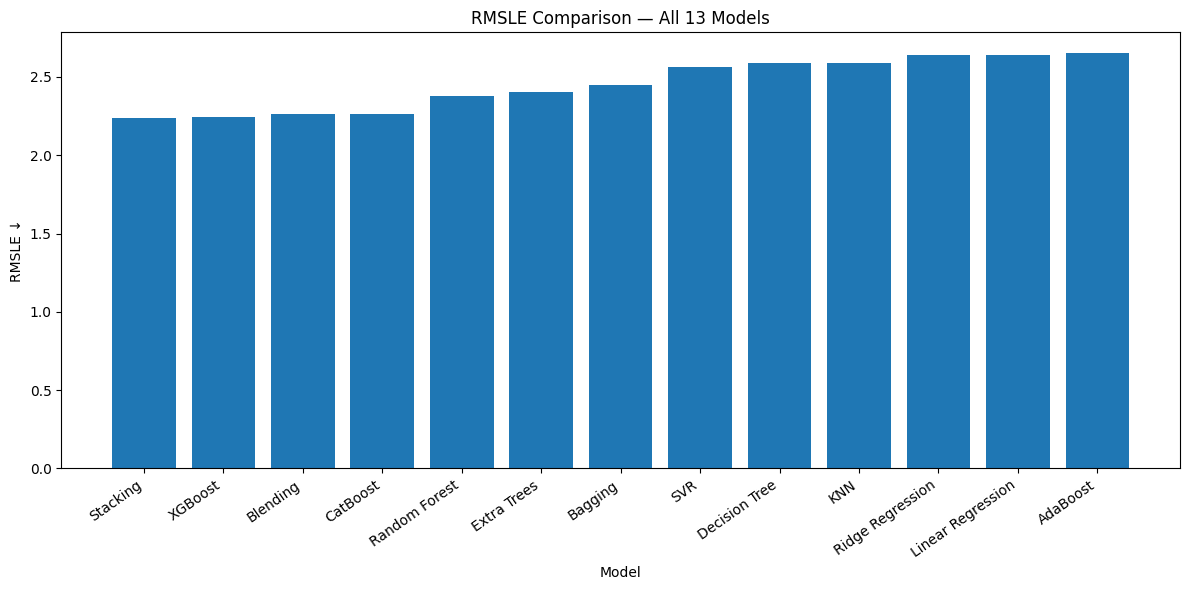

In [17]:

plot_df = final_metrics.sort_values("RMSLE", ascending=True)

plt.figure(figsize=(12, 6))
plt.bar(plot_df["Model"], plot_df["RMSLE"])
plt.ylabel("RMSLE ↓")
plt.xlabel("Model")
plt.title("RMSLE Comparison — All 13 Models")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 17. Final files

The notebook writes checkpoints continuously to `/kaggle/working/kickstarter_ensemble_checkpoints/`:

- `tuning_results_checkpoint.csv` — one row per tuning method/model, written immediately after each search completes.
- `final_metrics_checkpoint.csv` — one row per final model, written immediately after each final model/ensemble completes.
- `predictions_checkpoint.csv` — predictions are updated after each final model.

Because these files are written incrementally, a later kernel/session failure does not erase completed results. Re-running the notebook skips already checkpointed tuning methods and final models where possible.


In [18]:

print("Checkpoint files:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print(f"  {p.name:40s} {p.stat().st_size/1024:.1f} KB")

# Optional copy to the top-level Kaggle working directory for easy download.
for src in [TUNING_CSV, FINAL_CSV, PREDICTIONS_CSV]:
    if src.exists():
        dst = Path("/kaggle/working") / src.name
        if src != dst:
            shutil.copy2(src, dst)
        print("Top-level copy:", dst)


Checkpoint files:
  final_metrics_checkpoint.csv             2.8 KB
  predictions_checkpoint.csv               1009.0 KB
  tuning_results_checkpoint.csv            5.5 KB
Top-level copy: /kaggle/working/tuning_results_checkpoint.csv
Top-level copy: /kaggle/working/final_metrics_checkpoint.csv
Top-level copy: /kaggle/working/predictions_checkpoint.csv
